In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1' # haven't configured this env to use gpu yet


import numpy as np

import matplotlib.pyplot as plt 

import tensorflow as tf
import tensorflow.keras as keras
from keras import layers, models, callbacks


from qkeras import QActivation, QConv2D, QDense
from qkeras import quantized_bits, quantized_relu
from qkeras.utils import model_save_quantized_weights

import hls4ml

tf.random.set_seed(69)
np.random.seed(69)

2026-04-08 08:19:24.394378: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-08 08:19:24.394448: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-08 08:19:24.395875: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-08 08:19:24.554676: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-08 08:19:26.056777: W tensorflow/compiler/

/home/ericraze/miniconda3/envs/hls4ml_07/lib/python3.10/site-packages/hls4ml/converters/__init__.py:24: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


In [2]:
# Set up quantization params
W = quantized_bits(bits=8, integer=1, alpha=1) # Weights are small, so range is -1 to 1
A = "quantized_relu(8,1)" # we expect small weights, so 1 integer bit should be sufficient
A_OUT = "quantized_relu(8,0)"

In [3]:
def build_q_tiny_autoencoder(input_shape=(64, 64, 1)):
    # Encoder section
    input_img = layers.Input(shape=input_shape)
 
    # 2 small conv layers to capture essential features while keeping fpga resource usage low
    # Use explicit activations layers in qkeras to allow maximal op splitting/tiling
    x = QConv2D(8, (3, 3), padding="same",
                kernel_quantizer=W, bias_quantizer=W,
                name="enc_conv1")(input_img)
    x = QActivation(A, name="enc_act1")(x)
    x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool1")(x)
 
    x = QConv2D(4, (3, 3), padding="same",
                kernel_quantizer=W, bias_quantizer=W,
                name="enc_conv2")(x)
    x = QActivation(A, name="enc_act2")(x)
    x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool2")(x)
 
    shape_before_flattening = (16, 16, 4)
    flat_dim = int(np.prod(shape_before_flattening))
    x = layers.Flatten(name="flatten")(x)

    # latent space to represent the essence of the sound
    latent_space = QDense(32, kernel_quantizer=W, bias_quantizer=W, name="latent_space")(x) # 1x32
    x = QActivation(A, name="latent_act")(latent_space)
 
    # decoder section - construct a spectrogram from the latent representation

    # first we need to do a spatial broadcasting. To keep the model small we will simply replicate the latent vector across 4 spatial dims
    # then use a conv to make the shape match the shape before flattening. => turns out hls4ml doesn't support RepeatVector layers
    # x = layers.RepeatVector(16, name="linear_broadcast")(x)
    # x = layers.Reshape((4, 4, 32), name="spatial_broadcast")(x)
    # x = QConv2D(4, (3, 3), padding="same", kernel_quantizer=W, bias_quantizer=W, name="dec_broadcast_conv")(x) # 4x4x4
    # x = QActivation(A, name="dec_act0")(x)
    # x = layers.UpSampling2D((4, 4), name="dec_up0")(x) # 16x16x4

    x = layers.Reshape((1, 1, 32), name="dec_reshape")(x)
    x = layers.UpSampling2D((16, 16), name="dec_up0")(x)  # 16x16x32

    # 32x32x4
    x = QConv2D(4, (3, 3), padding="same",
                         kernel_quantizer=W, bias_quantizer=W,
                         name="dec_conv1")(x)
    x = QActivation(A, name="dec_act1")(x)
    x = layers.UpSampling2D((2, 2), name="dec_up1")(x)
 
    # 64x64x8
    x = QConv2D(8, (3, 3), padding="same",
                         kernel_quantizer=W, bias_quantizer=W,
                         name="dec_conv2")(x)
    x = QActivation(A, name="dec_act2")(x)
    x = layers.UpSampling2D((2, 2), name="dec_up2")(x)
 
    x = QConv2D(1, (3, 3), padding="same",
                kernel_quantizer=W, bias_quantizer=W,
                name="dec_out_conv")(x)
    decoded = QActivation(A_OUT, name="dec_out_act")(x)
 
    return models.Model(input_img, decoded, name="qat_autoencoder")

In [7]:
def train(x_train, x_val=None, epochs=50, batch_size=32):
    """
    x_train : np.ndarray  shape (N, 64, 64, 1), values in [0, 1]
    x_val   : np.ndarray  shape (M, 64, 64, 1), optional
    """
    model = build_q_tiny_autoencoder()
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="mse",
    )
    model.summary()
 
    cb = [
        # save the best intermediate weights
        callbacks.ModelCheckpoint(
            "qat_best.keras",
            monitor="val_loss" if x_val is not None else "loss",
            save_best_only=True,
            verbose=1,
        ),
        # reduce learning rate if validation loss stagnates
        callbacks.ReduceLROnPlateau(
            monitor="val_loss" if x_val is not None else "loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1,
        ),
        callbacks.EarlyStopping(
            monitor="val_loss" if x_val is not None else "loss",
            patience=10,
            restore_best_weights=True,
            verbose=1,
        ),
    ]
 
    validation_data = (x_val, x_val) if x_val is not None else None
 
    history = model.fit(
        x_train, x_train,   # since we are training the model to recreate the input
        epochs=epochs,
        batch_size=batch_size,
        validation_data=validation_data,
        # callbacks=cb, # there seems to be a bug with this tf/keras version where saving the model as .keras throws an error
        shuffle=True,
    )
 
    return model, history

In [ ]:
def spectrogram_to_tensor(spectrogram, window_size=64, step_size=32):
    # we want to create windows 64 wide 
    _ , steps = spectrogram.shape
    windows = []
    for start in range(0, steps - window_size + 1, step_size):
            window = spectrogram[:, start : start + window_size]
            windows.append(window)
    
    X = np.array(windows)
    X = np.expand_dims(X, axis=-1)
    return X

def create_dataset(data_dir, file = None, window_size=64, step_size=32):
    all_windows = []
    if file is not None:
        files = [file]
    else:
        files = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
    
    for f in files:
        spec = np.load(os.path.join(data_dir, f))
        
        all_windows.append(spectrogram_to_tensor(spec, window_size, step_size))

    X = np.concatenate(all_windows, axis=0)
    np.random.shuffle(X)
    return X

X_train = create_dataset('../data/spectrogram/normal/')

# use 20% of data for validation
split = int(0.8 * len(X_train))
train_data = X_train[:split]
val_data = X_train[split:]

print(f"Total training windows: {len(train_data)}")

Total training windows: 6835


In [ ]:
# right now only using 5 epochs for quick iterations. will increase once model architecture is set
model, history = train(train_data, val_data, epochs=5, batch_size=32)

Model: "qat_autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 64, 64, 1)]       0         
                                                                 
 enc_conv1 (QConv2D)         (None, 64, 64, 8)         80        
                                                                 
 enc_act1 (QActivation)      (None, 64, 64, 8)         0         
                                                                 
 enc_pool1 (MaxPooling2D)    (None, 32, 32, 8)         0         
                                                                 
 enc_conv2 (QConv2D)         (None, 32, 32, 4)         292       
                                                                 
 enc_act2 (QActivation)      (None, 32, 32, 4)         0         
                                                                 
 enc_pool2 (MaxPooling2D)    (None, 16, 16, 4)     

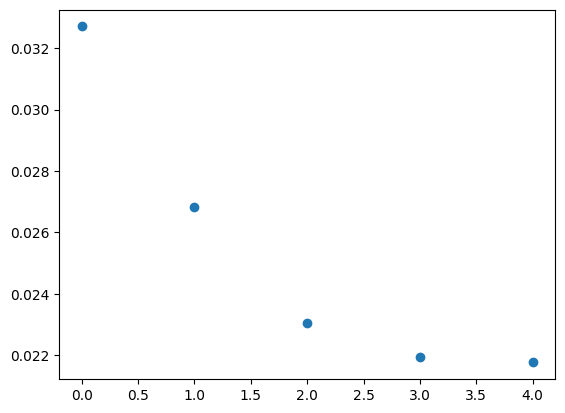

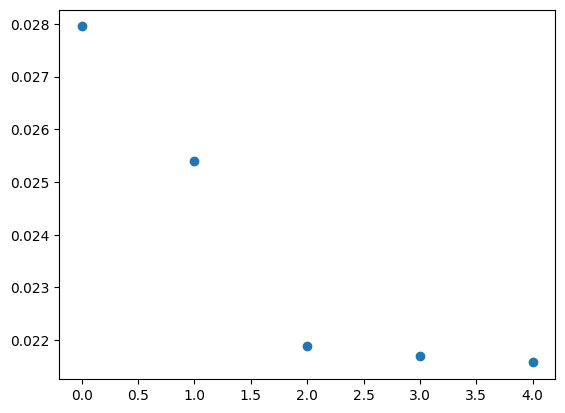

In [7]:
plt.scatter(range(len(history.history['loss'])), history.history['loss'], label='Train Loss')
plt.figure()
plt.scatter(range(len(history.history['val_loss'])), history.history['val_loss'], label='Validation Loss')

In [8]:
model.save('q_auto_encoder.keras')
model.save_weights("q_auto_encoder_weights.h5")

/home/ericraze/miniconda3/envs/hls4ml_07/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


In [9]:
%run audio.ipynb

def detect_anomalies(file_path, model, threshold=0.05):
    # 1. Prep the spectrogram
    spec = generate_fpga_style_spectrogram(file_path) # (64, 313)
    
    # 2. Slice into windows (Batch, 64, 64, 1)
    windows = spectrogram_to_tensor(spec) 
    print(f"Windows Shape: {windows.shape}")
    
    # 3. Model "tries" to reconstruct the sound
    reconstructed = model.predict(windows)
    
    # 4. Calculate error per window
    # Shape of 'errors' will be (Number_of_Windows,)
    errors = np.mean(np.abs(windows - reconstructed), axis=(1, 2, 3))
    
    # 5. Identify which windows are bad
    anomalous_indices = np.where(errors > threshold)[0]
    
    return errors, anomalous_indices

In [10]:
detect_anomalies('../-6_dB_slider/slider/id_00/normal/00000011.wav', model)

Windows Shape: (8, 64, 64, 1)
1/1 [==============================] - 0s 467ms/step


(array([0.10596496, 0.10342854, 0.10310763, 0.10615367, 0.10810623,
        0.10602032, 0.10488984, 0.10556154], dtype=float32),
 array([0, 1, 2, 3, 4, 5, 6, 7]))

In [11]:
# Load saved keras model
from qkeras.utils import load_qmodel
model = build_q_tiny_autoencoder()
model.load_weights("q_auto_encoder_weights.h5")
model.summary()

Model: "qat_autoencoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 64, 64, 1)]       0         
                                                                 
 enc_conv1 (QConv2D)         (None, 64, 64, 8)         80        
                                                                 
 enc_act1 (QActivation)      (None, 64, 64, 8)         0         
                                                                 
 enc_pool1 (MaxPooling2D)    (None, 32, 32, 8)         0         
                                                                 
 enc_conv2 (QConv2D)         (None, 32, 32, 4)         292       
                                                                 
 enc_act2 (QActivation)      (None, 32, 32, 4)         0         
                                                                 
 enc_pool2 (MaxPooling2D)    (None, 16, 16, 4)     

In [ ]:
import hls4ml
config = hls4ml.utils.config_from_keras_model(
     model,
     granularity='name',
     default_precision='fixed<8,1>',
     backend='Vitis')

for layer in model.layers:
    config['LayerName'][layer.name] = {
        'Strategy': 'Resource',
        'ReuseFactor': 24
    }

Interpreting Model
Topology:
Layer name: input_2, layer type: InputLayer, input shapes: [[None, 64, 64, 1]], output shape: [None, 64, 64, 1]
Layer name: enc_conv1, layer type: QConv2D, input shapes: [[None, 64, 64, 1]], output shape: [None, 64, 64, 8]
Layer name: enc_act1, layer type: Activation, input shapes: [[None, 64, 64, 8]], output shape: [None, 64, 64, 8]
Layer name: enc_pool1, layer type: MaxPooling2D, input shapes: [[None, 64, 64, 8]], output shape: [None, 32, 32, 8]
Layer name: enc_conv2, layer type: QConv2D, input shapes: [[None, 32, 32, 8]], output shape: [None, 32, 32, 4]
Layer name: enc_act2, layer type: Activation, input shapes: [[None, 32, 32, 4]], output shape: [None, 32, 32, 4]
Layer name: enc_pool2, layer type: MaxPooling2D, input shapes: [[None, 32, 32, 4]], output shape: [None, 16, 16, 4]
Layer name: flatten, layer type: Reshape, input shapes: [[None, 16, 16, 4]], output shape: [None, 1024]
Layer name: latent_space, layer type: QDense, input shapes: [[None, 1024]],

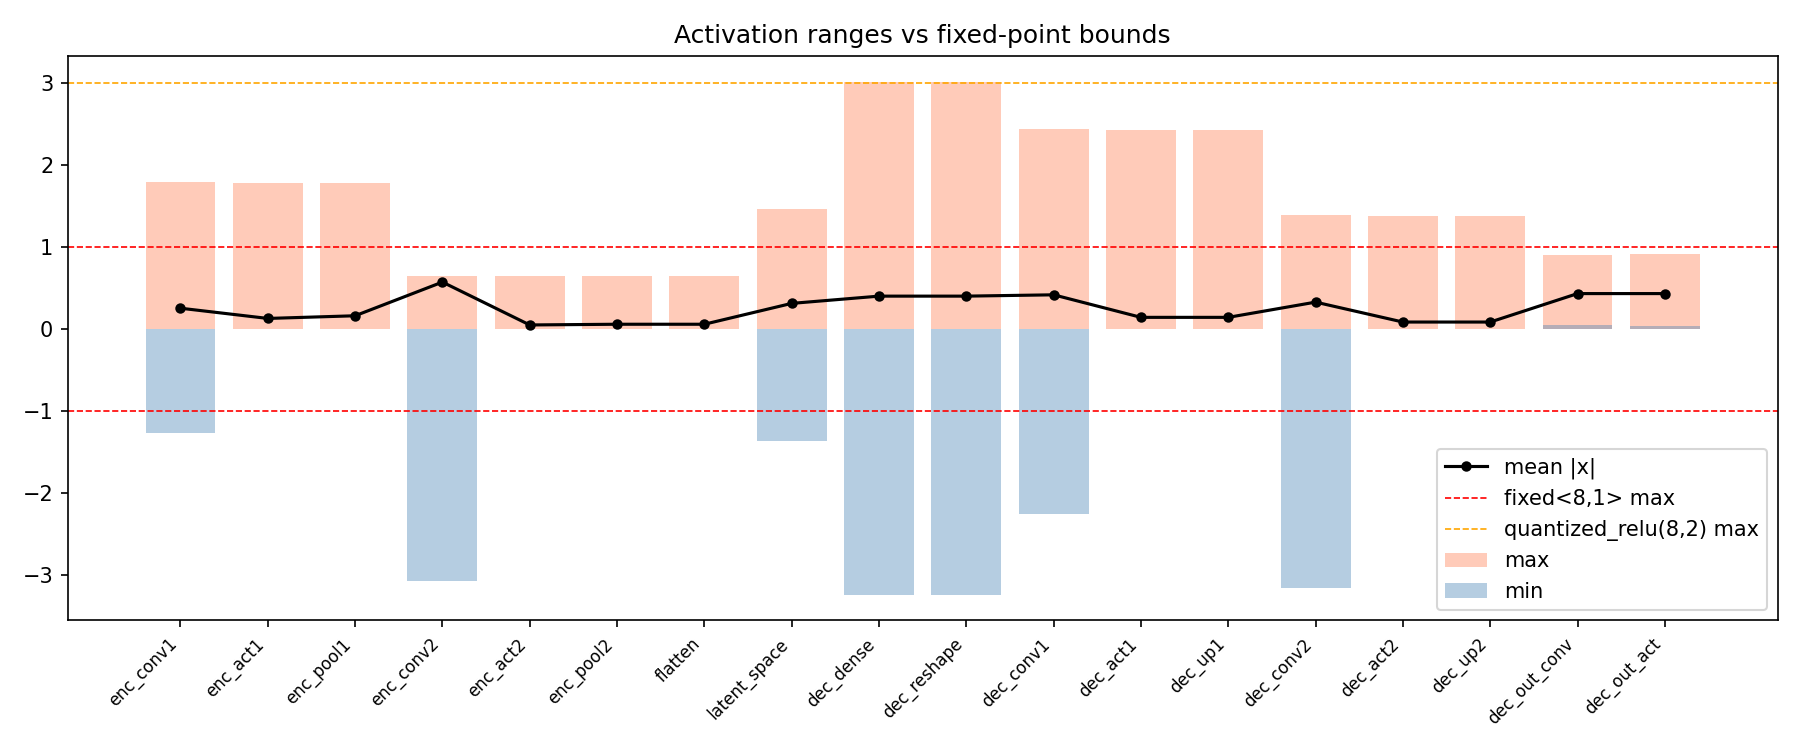

In [14]:
hls_model = hls4ml.converters.convert_from_keras_model(
    model,
    hls_config=config,
    output_dir='../hls_output',
    io_type='io_stream',
    backend='Vitis',
    part='xc7a35tcsg324-1',
    clock_period=10,
)
hls_model.write()
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True)

Interpreting Model
Topology:
Layer name: input_2, layer type: InputLayer, input shapes: [[None, 64, 64, 1]], output shape: [None, 64, 64, 1]
Layer name: enc_conv1, layer type: QConv2D, input shapes: [[None, 64, 64, 1]], output shape: [None, 64, 64, 8]
Layer name: enc_act1, layer type: Activation, input shapes: [[None, 64, 64, 8]], output shape: [None, 64, 64, 8]
Layer name: enc_pool1, layer type: MaxPooling2D, input shapes: [[None, 64, 64, 8]], output shape: [None, 32, 32, 8]
Layer name: enc_conv2, layer type: QConv2D, input shapes: [[None, 32, 32, 8]], output shape: [None, 32, 32, 4]
Layer name: enc_act2, layer type: Activation, input shapes: [[None, 32, 32, 4]], output shape: [None, 32, 32, 4]
Layer name: enc_pool2, layer type: MaxPooling2D, input shapes: [[None, 32, 32, 4]], output shape: [None, 16, 16, 4]
Layer name: flatten, layer type: Reshape, input shapes: [[None, 16, 16, 4]], output shape: [None, 1024]
Layer name: latent_space, layer type: QDense, input shapes: [[None, 1024]],

/home/ericraze/miniconda3/envs/hls4ml_07/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Done


In [ ]:
# run the vitis hls pipeline
hls_model.build()


****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.2 (64-bit)
  **** SW Build 5238294 on Nov  8 2024
  **** IP Build 5239520 on Sun Nov 10 16:12:51 MST 2024
  **** SharedData Build 5239561 on Fri Nov 08 14:39:27 MST 2024
  **** Start of session at: Tue Apr  7 20:48:23 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis/2024.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] For user 'ericraze' on host 'Ericraze.localdomain' (Linux_x86_64 version 6.6.87.2-microsoft-standard-WSL2) on Tue Apr 07 20:48:26 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.3 LTS
INFO: [HLS 200-10] In directory '/mnt/c/Users/aleon/Documents/School/Tron/3B-SUTD/1_Digital_Systems_Lab/fpga-audio-autoencoder/hls_output'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Opening project '/mnt/c/Users/aleon/Document

{'CSimResults': [['0.0390625',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.046875',
   '0.0703125',
   '0.101563',
   '0.13

In [17]:
hls_model.compile()

# Get a batch of test windows
X_test = val_data[:100]  # shape (100, 64, 64, 1)

# Keras reference (float32)
keras_out = model.predict(X_test)

# HLS model (fixed-point C++ running on CPU)
hls_out = hls_model.predict(X_test)

Writing HLS project


/home/ericraze/miniconda3/envs/hls4ml_07/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
/home/ericraze/miniconda3/envs/hls4ml_07/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


Done
4/4 [==============================] - 1s 23ms/step


In [18]:
mae = np.mean(np.abs(keras_out.flatten() - hls_out.flatten()))
max_err = np.max(np.abs(keras_out.flatten() - hls_out.flatten()))
print(f"Mean absolute error: {mae:.6f}")
print(f"Max absolute error:  {max_err:.6f}")

Mean absolute error: 0.282717
Max absolute error:  0.996094
